In [1]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

from timeit import default_timer as timer

In [2]:
# Setup training data
train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

# Setup test data
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=False,
    transform=ToTensor()
)

100%|██████████████████████████████████████| 9.91M/9.91M [00:01<00:00, 8.43MB/s]
100%|███████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 350kB/s]
100%|██████████████████████████████████████| 1.65M/1.65M [00:00<00:00, 3.41MB/s]
100%|██████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 5.63MB/s]


torch.Size([1, 28, 28])


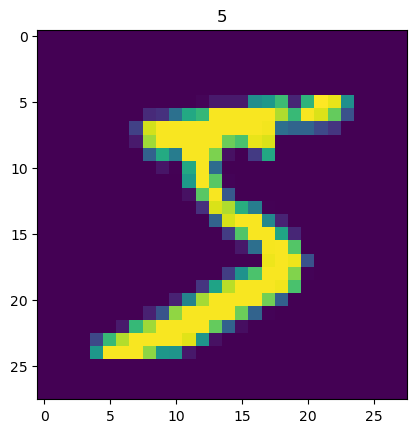

In [3]:
# Visualizing data
# See first training sample
image, label = train_data[0]
print(image.shape)
plt.imshow(image.squeeze())
plt.title(label)
plt.show()

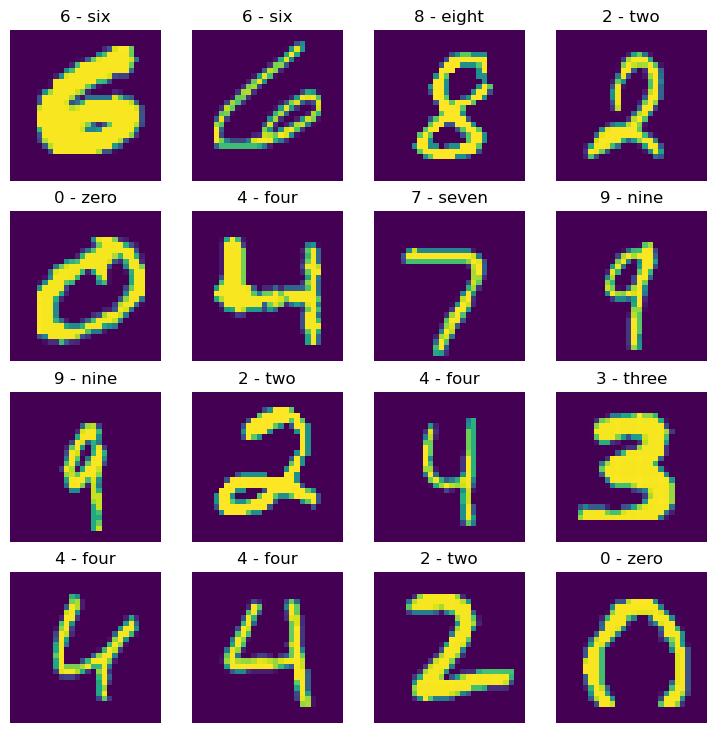

In [4]:
# Plot multiple images
torch.manual_seed(42)
class_names = train_data.classes
fig = plt.figure(figsize=(9, 9))
n_rows, n_cols = 4, 4
for i in range(1, n_rows * n_cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(n_rows, n_cols, i)
    plt.imshow(img.squeeze())
    plt.title(class_names[label])
    plt.axis(False)

plt.show()

In [5]:
batch_size = 32

train_data_loader = DataLoader(train_data, batch_size=batch_size,shuffle=True)
test_data_loader = DataLoader(test_data, batch_size=batch_size,shuffle=True)

print(f"Length of train data loader: {len(train_data_loader)} batches of {batch_size}")
print(f"Length of test data loader: {len(test_data_loader)} batches of {batch_size}")

Length of train data loader: 1875 batches of 32
Length of test data loader: 313 batches of 32


In [6]:
# Check out what is inside the training data loader
train_features_batch, train_label_batch = next(iter(train_data_loader))
print(train_features_batch.shape, train_label_batch.shape)

torch.Size([32, 1, 28, 28]) torch.Size([32])


In [7]:
# Build a simple NN model
class SimpleModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc_1 = nn.Linear(input_size, out_features=hidden_size)
        self.fc_2 = nn.Linear(in_features=hidden_size, out_features=output_size)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(0.5)

    def forward(self, x):
        temp = self.fc_2(self.drop(self.relu(self.fc_1(self.flatten(x)))))
        return temp

In [8]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [9]:
image, label = train_data[0]
input_size = len(torch.flatten(image))
output_size = len(class_names)

model = SimpleModel(input_size=input_size, hidden_size=10, output_size=output_size).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

In [10]:
def train_step(model, data_loader, loss_fn, optimizer, device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss

        # Compute accuracy
        correct = torch.eq(y_pred.argmax(dim=1), y).sum().item() / len(y)
        train_acc += correct

        # Model update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)

    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}")

In [11]:
def test_step(model, data_loader, loss_fn, device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)

            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            test_loss += loss

            # Compute accuracy
            correct = torch.eq(y_pred.argmax(dim=1), y).sum().item() / len(y)
            test_acc += correct

        test_loss /= len(data_loader)
        test_acc /= len(data_loader)

        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}\n")

In [12]:
num_epochs = 10
train_start_time = timer()
for epoch in range(num_epochs):
    print(f"Epoch: {epoch}\n-------------")
    train_step(model, train_data_loader, loss_fn, optimizer, device)
    test_step(model, test_data_loader, loss_fn, device)

train_end_time = timer()
print(f"Train time on {device}: {train_end_time - train_start_time:.3f} seconds")

Epoch: 0
-------------
Train loss: 0.43920 | Train accuracy: 0.87
Test loss: 0.29502 | Test accuracy: 0.92

Epoch: 1
-------------
Train loss: 0.30500 | Train accuracy: 0.91
Test loss: 0.26783 | Test accuracy: 0.93

Epoch: 2
-------------
Train loss: 0.27997 | Train accuracy: 0.92
Test loss: 0.28274 | Test accuracy: 0.92

Epoch: 3
-------------
Train loss: 0.26698 | Train accuracy: 0.92
Test loss: 0.26091 | Test accuracy: 0.92

Epoch: 4
-------------
Train loss: 0.25837 | Train accuracy: 0.92
Test loss: 0.26123 | Test accuracy: 0.92

Epoch: 5
-------------
Train loss: 0.24827 | Train accuracy: 0.93
Test loss: 0.24429 | Test accuracy: 0.93

Epoch: 6
-------------
Train loss: 0.23475 | Train accuracy: 0.93
Test loss: 0.24461 | Test accuracy: 0.93

Epoch: 7
-------------
Train loss: 0.22688 | Train accuracy: 0.93
Test loss: 0.24327 | Test accuracy: 0.93

Epoch: 8
-------------
Train loss: 0.22264 | Train accuracy: 0.94
Test loss: 0.23763 | Test accuracy: 0.93

Epoch: 9
-------------
Train

In [13]:
# Create a more complex model
class TinyVGG(nn.Module):
    def __init__(self, input_shape, hidden_size, output_shape):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_size,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_size,
                      out_channels=hidden_size,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.Dropout(.3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_size, hidden_size, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_size, hidden_size, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_size * 7 * 7, out_features=output_shape)
        )

    def forward(self, x):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)
        return x

In [14]:
torch.manual_seed(42)
complex_model = TinyVGG(input_shape=1, hidden_size=10, output_shape=len(class_names)).to(device)

In [15]:
from torchinfo import summary
summary(complex_model, input_size=[1, 1, 28, 28])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 10]                   --
├─Sequential: 1-1                        [1, 10, 14, 14]           --
│    └─Conv2d: 2-1                       [1, 10, 28, 28]           100
│    └─ReLU: 2-2                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-3                       [1, 10, 28, 28]           910
│    └─ReLU: 2-4                         [1, 10, 28, 28]           --
│    └─MaxPool2d: 2-5                    [1, 10, 14, 14]           --
├─Sequential: 1-2                        [1, 10, 7, 7]             --
│    └─Conv2d: 2-6                       [1, 10, 14, 14]           910
│    └─ReLU: 2-7                         [1, 10, 14, 14]           --
│    └─Conv2d: 2-8                       [1, 10, 14, 14]           910
│    └─ReLU: 2-9                         [1, 10, 14, 14]           --
│    └─MaxPool2d: 2-10                   [1, 10, 7, 7]             --
├─Sequentia

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(complex_model.parameters(), lr=0.1)
num_epochs = 10
train_start_time = timer()
for epoch in range(num_epochs):
    print(f"Epoch: {epoch}\n-------------")
    train_step(complex_model, train_data_loader, loss_fn, optimizer, device)
    test_step(complex_model, test_data_loader, loss_fn, device)

train_end_time = timer()
print(f"Train time on {device}: {train_end_time - train_start_time:.3f} seconds")

Epoch: 0
-------------
